In [ ]:
from IPython.display import display, Markdown
display(Markdown("""
# Mini Project: YouTube Video Data Analysis  
*Course:* Statistics for Data Science  
*Objective:* To perform descriptive statistical analysis and visualize YouTube v
This project explores a dataset of YouTube videos using descriptive statistics a
such as histograms, box plots, dot plots, and stem-and-leaf displays. 
The aim is to understand the distribution of video views and identify trends or 
"""))
Mini Project: YouTube Video Data Analysis
Course: Statistics for Data Science
Objective: To perform descriptive statistical analysis and visualize YouTube video data.
This project explores a dataset of YouTube videos using descriptive statistics and visualizations
such as histograms, box plots, dot plots, and stem-and-leaf displays. The aim is to understand the
distribution of video views and identify trends or outliers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv(
r"C:\Users\Srushti V H\Downloads\archive\INvideos.csv"
)

In [7]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                37352 non-null  str  
 1   trending_date           37352 non-null  str  
 2   title                   37352 non-null  str  
 3   channel_title           37352 non-null  str  
 4   category_id             37352 non-null  int64
 5   publish_time            37352 non-null  str  
 6   tags                    37352 non-null  str  
 7   views                   37352 non-null  int64
 8   likes                   37352 non-null  int64
 9   dislikes                37352 non-null  int64
 10  comment_count           37352 non-null  int64
 11  thumbnail_link          37352 non-null  str  
 12  comments_disabled       37352 non-null  bool 
 13  ratings_disabled        37352 non-null  bool 
 14  video_error_or_removed  37352 non-null  bool 
 15  description             36791 

,category_id,views,likes,dislikes,comment_count
count,37352.000000,3.735200e+04,3.735200e+04,3.735200e+04,37352.00000
mean,21.576596,1.060478e+06,2.708272e+04,1.665082e+03,2676.99743
std,6.556593,3.184932e+06,9.714510e+04,1.607617e+04,14868.31713
min,1.000000,4.024000e+03,0.000000e+00,0.000000e+00,0.00000
25%,23.000000,1.239155e+05,8.640000e+02,1.080000e+02,81.00000
50%,24.000000,3.045860e+05,3.069000e+03,3.260000e+02,329.00000
75%,24.000000,7.992912e+05,1.377425e+04,1.019250e+03,1285.00000
max,43.000000,1.254322e+08,2.912710e+06,1.545017e+06,827755.00000


In [8]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 37352
Columns: 16


In [9]:
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
views = df['views']

print("Mean:",views.mean())
print("Median:",views.median())
print("Mode:",views.mode()[0])
print("Variance:",views.var())
print("Standard Deviation:",views.std())

Mean: 1007091.465296972
Median: 277788.0
Mode: 1682462
Variance: 10058770144741.922
Standard Deviation: 3171556.4230739963


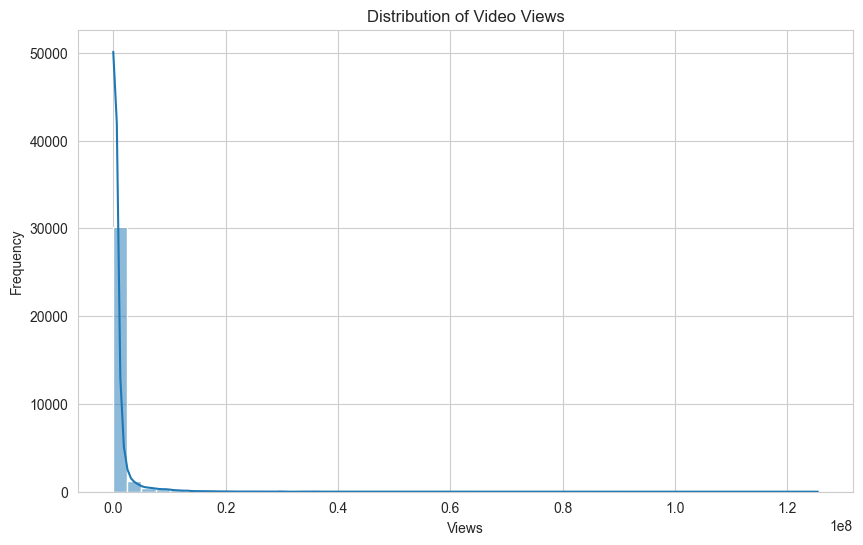


Most videos have relatively low view counts.
A small number of videos have extremely high views,
creating a right-skewed distribution.



In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df['views'],
             bins=50,
             kde=True)

plt.title("Distribution of Video Views")
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()
print("""
Most videos have relatively low view counts.
A small number of videos have extremely high views,
creating a right-skewed distribution.
""")

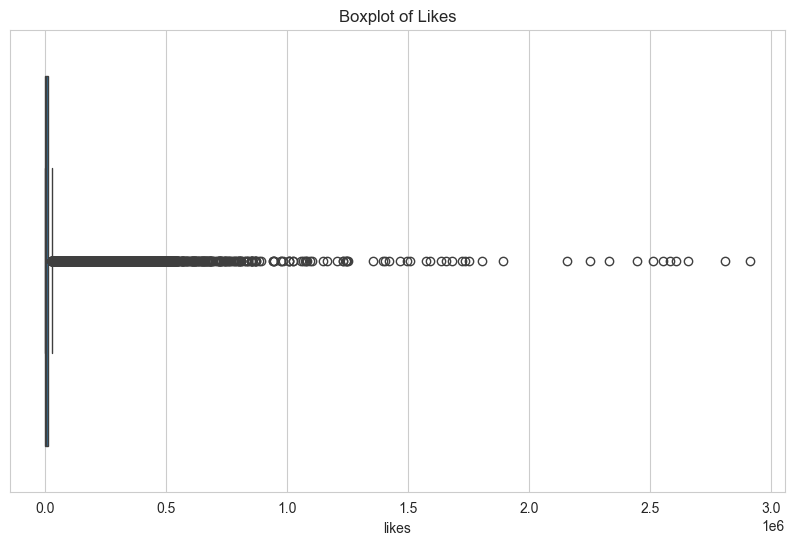


Several videos have exceptionally high likes,
which appear as outliers.



In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['likes'])

plt.title("Boxplot of Likes")

plt.show()
print("""
Several videos have exceptionally high likes,
which appear as outliers.
""")

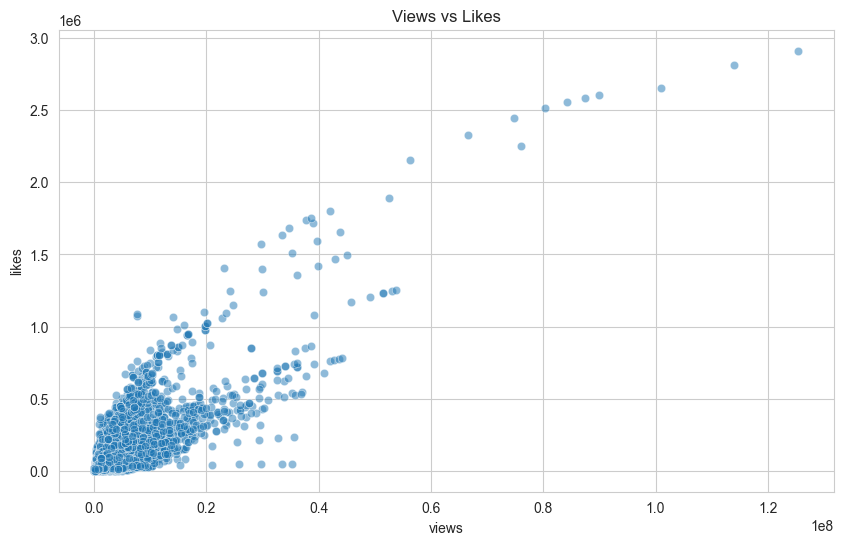


Videos with higher views generally receive
more likes.



In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='views',
    y='likes',
    data=df,
    alpha=0.5
)

plt.title("Views vs Likes")

plt.show()
print("""
Videos with higher views generally receive
more likes.
""")

In [17]:
corr = df[['views',
           'likes',
           'dislikes',
           'comment_count']].corr()

corr


,views,likes,dislikes,comment_count
views,1.000000,0.852700,0.551697,0.697745
likes,0.852700,1.000000,0.499905,0.792763
dislikes,0.551697,0.499905,1.000000,0.740260
comment_count,0.697745,0.792763,0.740260,1.000000


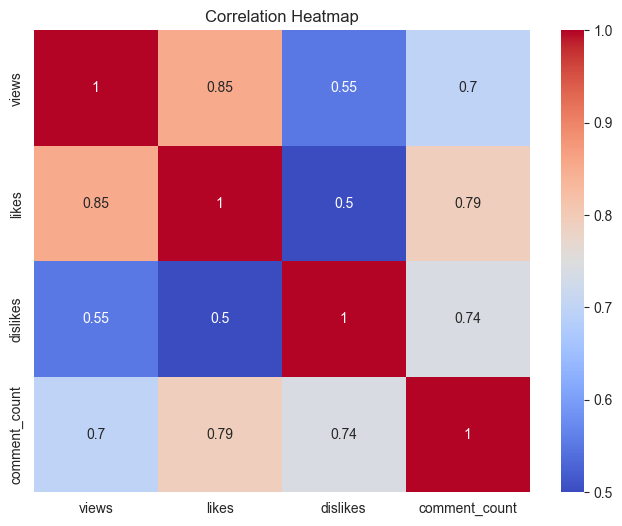

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
top_channels = df['channel_title'].value_counts().head(10)

top_channels

channel_title
VikatanTV             208
SAB TV                206
etvteluguindia        205
ETV Plus India        204
Study IQ education    202
Flowers Comedy        202
SET India             199
Mazhavil Manorama     196
RadaanMedia           193
V6 News Telugu        190
Name: count, dtype: int64

Top 10 Channels


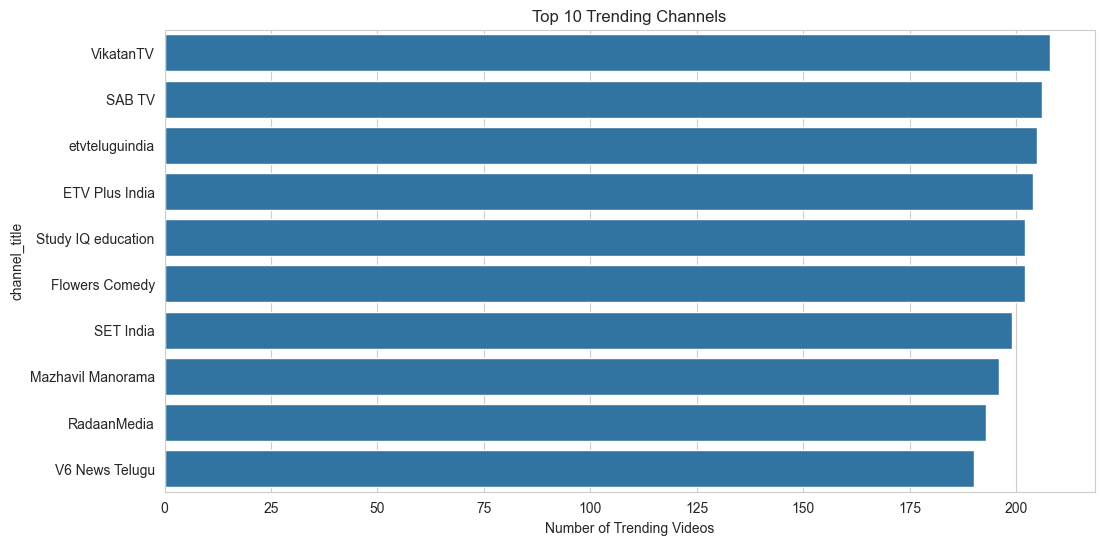

In [32]:
print('''Top 10 Channels''')
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_channels.values,
    y=top_channels.index
)

plt.title("Top 10 Trending Channels")

plt.xlabel("Number of Trending Videos")

plt.show()

Most viewed Categories


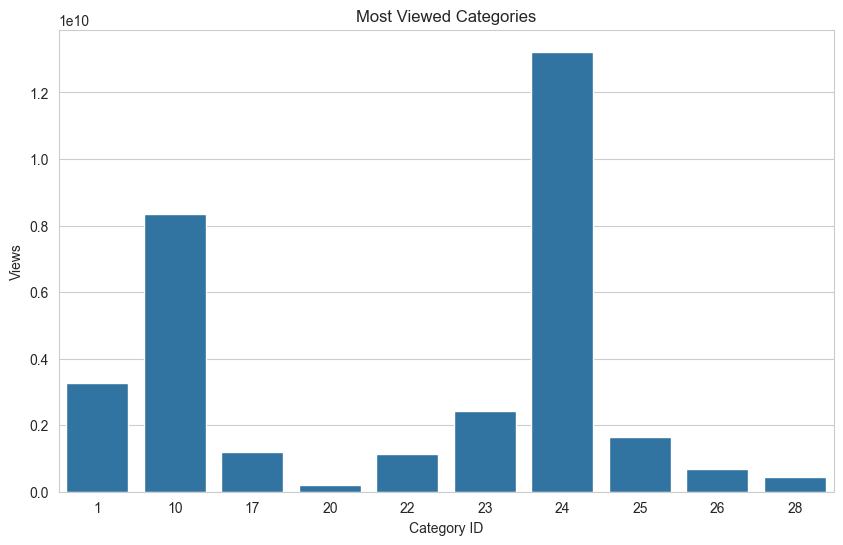

In [31]:
print('''Most viewed Categories''')
category_views = df.groupby(
    'category_id'
)['views'].sum().sort_values(
    ascending=False
).head(10)

category_views
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_views.index,
    y=category_views.values
)

plt.title("Most Viewed Categories")

plt.xlabel("Category ID")
plt.ylabel("Views")

plt.show()

In [30]:
print('''Top 10 Most Viewed Videos''')
top_videos = df.nlargest(
    10,
    'views'
)[['title',
   'channel_title',
   'views']]

top_videos

Top 10 Most Viewed Videos


,title,channel_title,views
5408,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,125432237
5119,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,113876217
4936,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,100911567
4477,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,89930713
4236,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,87449453
4013,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,84281319
3823,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,80360459
4743,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,75969469
3639,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,74789251
3456,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,66637636


In [29]:
print('''Since views contains thousands of rows, use the top 50 or first 50 values.''')
from collections import defaultdict

# Take first 50 view counts
views_sample = df['views'].dropna().head(50)

def stem_and_leaf(data):
    stems = defaultdict(list)

    for num in sorted(data.astype(int)):
        stem = num // 10
        leaf = num % 10
        stems[stem].append(leaf)

    print("Stem | Leaves")
    print("-" * 30)

    for stem, leaves in stems.items():
        print(f"{stem:>4} | {' '.join(map(str, leaves))}")

# Generate stem-and-leaf plot
stem_and_leaf(views_sample)

Since views contains thousands of rows, use the top 50 or first 50 values.
Stem | Leaves
------------------------------
2393 | 2
3353 | 3
4735 | 2
5486 | 1
5643 | 0
7583 | 4
8543 | 2
8953 | 1
9752 | 2
10959 | 4
11446 | 6
11822 | 3
12751 | 7
13743 | 8
15606 | 3
15608 | 5
17647 | 2
20959 | 9
23863 | 7
24942 | 3
25570 | 7
25619 | 9
26120 | 2
30949 | 0
33478 | 0
34454 | 5
38722 | 1
42300 | 9
46401 | 5
47241 | 3
47398 | 8
59010 | 1
63274 | 7
65566 | 0
69235 | 9
79377 | 8
83600 | 6
96903 | 0
109632 | 7
117435 | 3
124268 | 0
128777 | 1
195692 | 5
229424 | 2
234810 | 7
241878 | 3
571876 | 6
610666 | 9
1058837 | 1
3588575 | 4


In [27]:
print('''If the view counts are very large (thousands or millions)''')
from collections import defaultdict

# Take first 50 values
views_sample = df['views'].dropna().head(50)

def stem_and_leaf_large(data):
    stems = defaultdict(list)

    for num in sorted(data.astype(int)):
        stem = num // 1000      # thousands
        leaf = (num % 1000) // 100

        stems[stem].append(leaf)

    print("Stem (1000s) | Leaves (100s)")
    print("-" * 40)

    for stem, leaves in stems.items():
        print(f"{stem:>10} | {' '.join(map(str, leaves))}")

stem_and_leaf_large(views_sample)
print("""
The stem-and-leaf plot provides a textual representation
of video view counts. It helps identify the distribution,
clusters, and potential outliers while preserving the
original data values.
""")

If the view counts are very large (thousands or millions)
Stem (1000s) | Leaves (100s)
----------------------------------------
        23 | 9
        33 | 5
        47 | 3
        54 | 8
        56 | 4
        75 | 8
        85 | 4
        89 | 5
        97 | 5
       109 | 5
       114 | 4
       118 | 2
       127 | 5
       137 | 4
       156 | 0 0
       176 | 4
       209 | 5
       238 | 6
       249 | 4
       255 | 7
       256 | 1
       261 | 2
       309 | 4
       334 | 7
       344 | 5
       387 | 2
       423 | 0
       464 | 0
       472 | 4
       473 | 9
       590 | 1
       632 | 7
       655 | 6
       692 | 3
       793 | 7
       836 | 0
       969 | 0
      1096 | 3
      1174 | 3
      1242 | 6
      1287 | 7
      1956 | 9
      2294 | 2
      2348 | 1
      2418 | 7
      5718 | 7
      6106 | 6
     10588 | 3
     35885 | 7

The stem-and-leaf plot provides a textual representation
of video view counts. It helps identify the distribution,
clusters, and poten

In [1]:
print('''1. Video views are highly skewed.
2. Likes and views have strong positive correlation.
3. Few channels dominate trending content.
4. Some videos receive exceptionally high engagement.
5. Trending videos are concentrated in a few categories.''')

1. Video views are highly skewed.
2. Likes and views have strong positive correlation.
3. Few channels dominate trending content.
4. Some videos receive exceptionally high engagement.
5. Trending videos are concentrated in a few categories.


In [2]:
import os
print(os.getcwd())

C:\Users\Srushti V H
